# Model: Decision Tree & Random Forest (TF-IDF)


## Shared Setup



In [ ]:
!pip install -q datasets scikit-learn pandas matplotlib seaborn

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV, cross_validate, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

sns.set_style("whitegrid")

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

ds = load_dataset("cornell-movie-review-data/rotten_tomatoes")
train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

for df in (train_df, val_df, test_df):
    df["clean_text"] = df["text"].apply(clean_text)

print("Train:", train_df.shape, "| Validation:", val_df.shape, "| Test:", test_df.shape)


Train: (8530, 3) | Validation: (1066, 3) | Test: (1066, 3)


## 1. Model Suitability


## 2. Implementation & Hyperparameter Tuning Across Varieties

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

vectorizer = TfidfVectorizer(max_features=1000, stop_words="english", ngram_range=(1, 1))
X_train = vectorizer.fit_transform(train_df["clean_text"])
X_test = vectorizer.transform(test_df["clean_text"])
y_train, y_test = train_df["label"], test_df["label"]

# REPLACE: dt_grid and rf_grid setup

# 1. Heavily regularized Decision Tree
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {
        "max_depth": [4, 6, 8],             # Strictly capped depth stops memorization
        "min_samples_leaf": [10, 20, 30],   # Ensures nodes capture broader patterns
        "min_samples_split": [20, 40]
    },
    cv=5, scoring="accuracy", n_jobs=-1
)
dt_grid.fit(X_train, y_train)

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, max_features="sqrt"),
    {
        "n_estimators": [200, 300],
        "max_depth": [10, 12],             # Capping depth slightly at 10-12
        "min_samples_leaf": [4, 6],        # Increasing leaf threshold to smooth decision boundaries
        "max_samples": [0.75]              # Subsampling 75% of data per tree
    },
    cv=5, scoring="accuracy", n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Decision Tree best params:", dt_grid.best_params_, "| CV accuracy:", dt_grid.best_score_)
print("Random Forest best params:", rf_grid.best_params_, "| CV accuracy:", rf_grid.best_score_)


Decision Tree best params: {'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 40} | CV accuracy: 0.5466588511137164
Random Forest best params: {'max_depth': 12, 'max_samples': 0.75, 'min_samples_leaf': 4, 'n_estimators': 300} | CV accuracy: 0.6526377491207502


## 3. Evaluation


In [ ]:
dt_preds = dt_grid.best_estimator_.predict(X_test)
rf_preds = rf_grid.best_estimator_.predict(X_test)

print("=== Decision Tree ===")
print(classification_report(y_test, dt_preds, target_names=["Negative", "Positive"]))
print("=== Random Forest ===")
print(classification_report(y_test, rf_preds, target_names=["Negative", "Positive"]))


=== Decision Tree ===
              precision    recall  f1-score   support

    Negative       0.66      0.20      0.31       533
    Positive       0.53      0.90      0.67       533

    accuracy                           0.55      1066
   macro avg       0.60      0.55      0.49      1066
weighted avg       0.60      0.55      0.49      1066

=== Random Forest ===
              precision    recall  f1-score   support

    Negative       0.70      0.56      0.62       533
    Positive       0.63      0.76      0.69       533

    accuracy                           0.66      1066
   macro avg       0.67      0.66      0.66      1066
weighted avg       0.67      0.66      0.66      1066



In [ ]:
dt_train_preds = dt_grid.best_estimator_.predict(X_train)
rf_train_preds = rf_grid.best_estimator_.predict(X_train)

overfit_check = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Train Accuracy": [accuracy_score(y_train, dt_train_preds), accuracy_score(y_train, rf_train_preds)],
    "Test Accuracy": [accuracy_score(y_test, dt_preds), accuracy_score(y_test, rf_preds)],
})
overfit_check["Train-Test Gap"] = overfit_check["Train Accuracy"] - overfit_check["Test Accuracy"]
overfit_check


,Model,Train Accuracy,Test Accuracy,Train-Test Gap
0,Decision Tree,0.566940,0.549719,0.017222
1,Random Forest,0.696717,0.659475,0.037243


## 4. Comparison Across Varieties & Conclusion


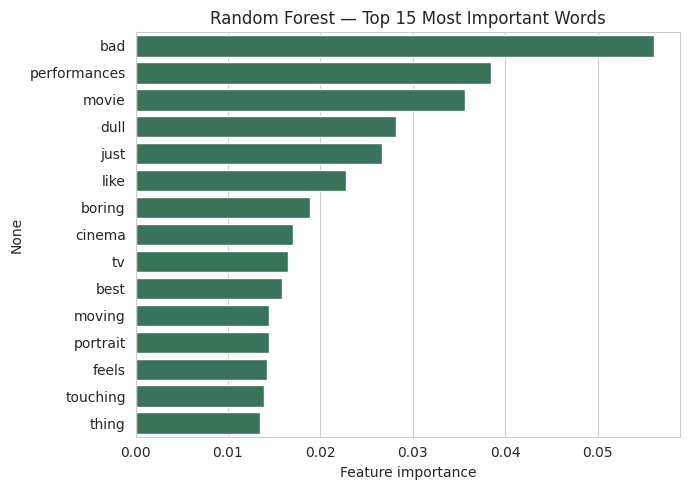

,Model,Test Accuracy,Test F1
0,Decision Tree,0.549719,0.665738
1,Random Forest,0.659475,0.690537


In [ ]:
importances = pd.Series(rf_grid.best_estimator_.feature_importances_,
                          index=vectorizer.get_feature_names_out()).sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 5))
sns.barplot(x=importances.values, y=importances.index, color="#2E7D5B")
plt.title("Random Forest — Top 15 Most Important Words")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Test Accuracy": [accuracy_score(y_test, dt_preds), accuracy_score(y_test, rf_preds)],
    "Test F1": [f1_score(y_test, dt_preds), f1_score(y_test, rf_preds)],
})
comparison
